In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the data
config = pd.read_csv('experiments/models/dataset_size/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_size.csv')

In [3]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [4]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on='experiment', suffixes=('_results', '_config'))

In [5]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

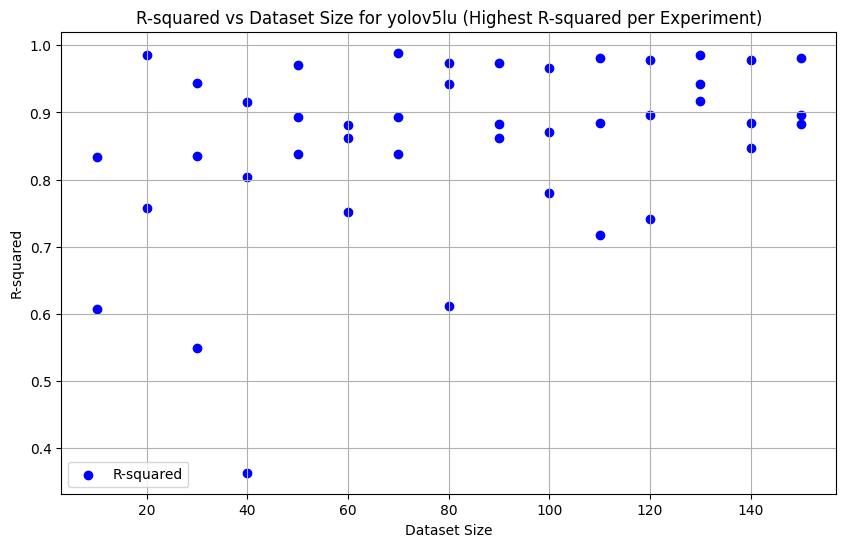

In [7]:
# Filter the DataFrame with model == 'yolov5lu'
filtered_df = df[df['model'] == 'yolov5su']

# Filter out R-squared values below 0
filtered_df = filtered_df[filtered_df['r_squared'] >= 0]

# Group by 'experiment' and select the observation with the highest R-squared value
max_r_squared_df = filtered_df.loc[filtered_df.groupby('experiment')['r_squared'].idxmax()]

# Plot R-squared as a function of dataset size
plt.figure(figsize=(10, 6))
plt.scatter(max_r_squared_df['dataset_size'], max_r_squared_df['r_squared'], color='blue', label='R-squared')

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size for yolov5lu (Highest R-squared per Experiment)')
plt.legend()
plt.grid(True)

plt.show()

/tmp/ipykernel_1412/508605157.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['exp'] = filtered_df.apply(lambda row: f"TS_{row['train_size']}_VS_{row['val_size']}", axis=1)


<Figure size 1200x800 with 0 Axes>

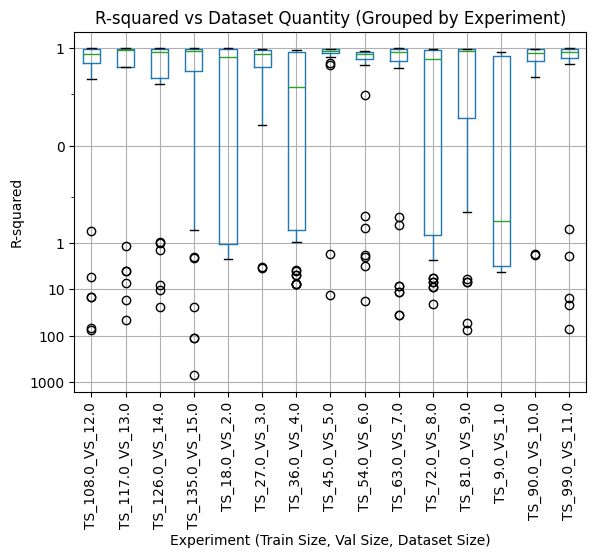

In [8]:
from matplotlib.ticker import LogLocator, LogFormatter, SymmetricalLogLocator

# Filter the DataFrame with model == 'yolov5lu'
filtered_df = df[df['model'] == 'yolov5su']

# Create a new column 'exp' combining 'train_size', 'val_size', and 'dataset_size'
filtered_df['exp'] = filtered_df.apply(lambda row: f"TS_{row['train_size']}_VS_{row['val_size']}", axis=1)

# Create a box plot with 'dataset_quantity' on the x-axis and 'r_squared' on the y-axis
plt.figure(figsize=(12, 8))
filtered_df.boxplot(column='r_squared', by='exp', grid=False, rot=90, fontsize=10)

plt.xlabel('Experiment (Train Size, Val Size, Dataset Size)')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Quantity (Grouped by Experiment)')
plt.suptitle('')  # Suppress the default title to avoid overlap
plt.grid(True)
# Set the y-axis to negative log scale
plt.yscale('symlog', linthresh=0.1)
plt.gca().yaxis.set_major_locator(SymmetricalLogLocator(base=10.0, linthresh=1))
plt.gca().yaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=False))

plt.show()

<Figure size 1200x800 with 0 Axes>

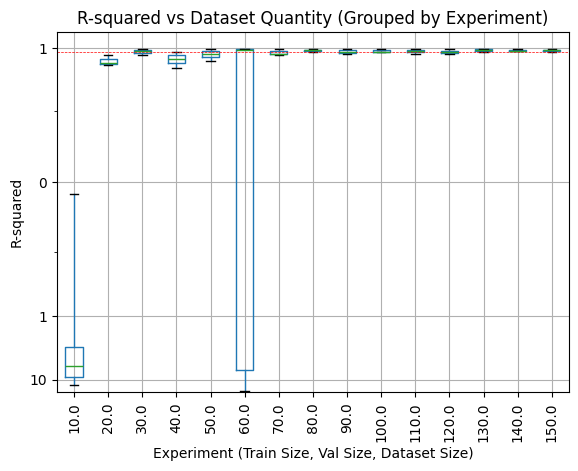

In [9]:
from matplotlib.ticker import LogLocator, LogFormatter, SymmetricalLogLocator

# Filter the DataFrame with model == 'yolov5lu'
filtered_df = df[df['model'] == 'yolov5nu']
# Drop rows with NaN values in the 'r_squared' column
filtered_df = filtered_df.dropna(subset=['r_squared'])

# Group by 'experiment' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby('experiment')['r_squared'].idxmax()]
# Create a new column 'exp' combining 'train_size', 'val_size', and 'dataset_size'
filtered_df['exp'] = filtered_df.apply(lambda row: row['dataset_size'], axis=1)
# sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')
# Create a box plot with 'dataset_quantity' on the x-axis and 'r_squared' on the y-axis
plt.figure(figsize=(12, 8))
filtered_df.boxplot(column='r_squared', by='exp', grid=False, rot=90, fontsize=10)
# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=.5)
plt.xlabel('Experiment (Train Size, Val Size, Dataset Size)')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Quantity (Grouped by Experiment)')
plt.suptitle('')  # Suppress the default title to avoid overlap
plt.grid(True)
# Set the y-axis to negative log scale
plt.yscale('symlog', linthresh=0.1)
plt.gca().yaxis.set_major_locator(SymmetricalLogLocator(base=10, linthresh=1))
plt.gca().yaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=False))

plt.show()

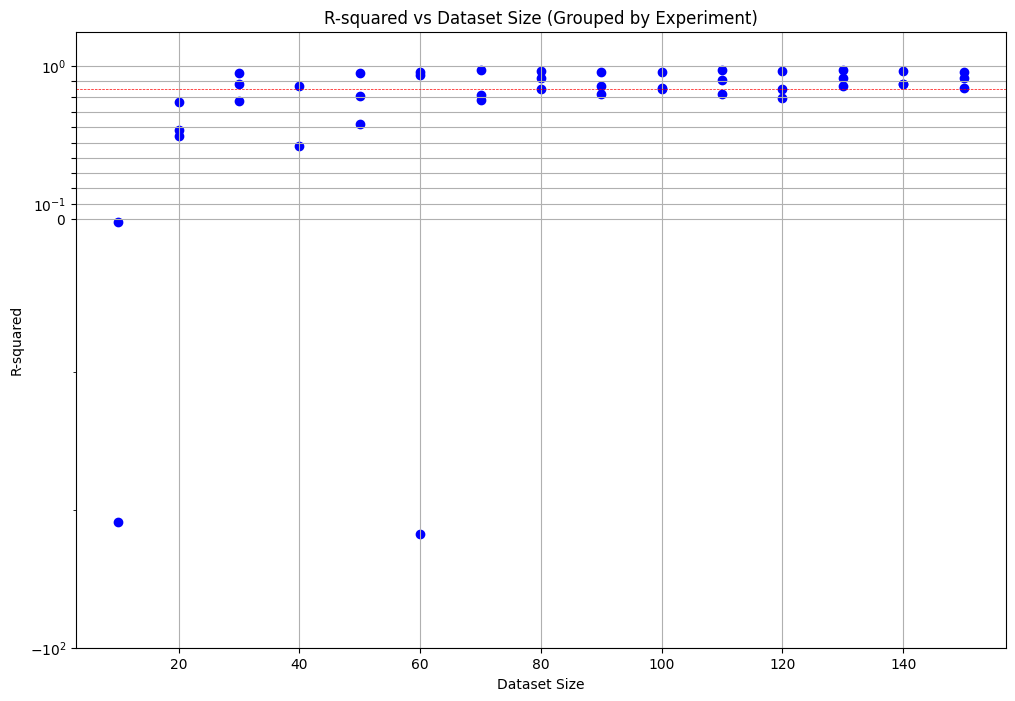

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame with model == 'yolov5lu'
filtered_df = df[df['model'] == 'yolov5nu']
# Drop rows with NaN values in the 'r_squared' column
filtered_df = filtered_df.dropna(subset=['r_squared'])

# Group by 'experiment' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby('experiment')['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Create a scatter plot with 'dataset_size' on the x-axis and 'r_squared' on the y-axis
plt.figure(figsize=(12, 8))
plt.scatter(filtered_df['dataset_size'], filtered_df['r_squared'], color='blue', label='R-squared')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment)')
plt.grid(True)

# Set the y-axis to negative log scale with increased range between 0 and 1
plt.yscale('symlog', linthresh=1)

# Customize the y-axis ticks
plt.yticks([-100, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

plt.show()

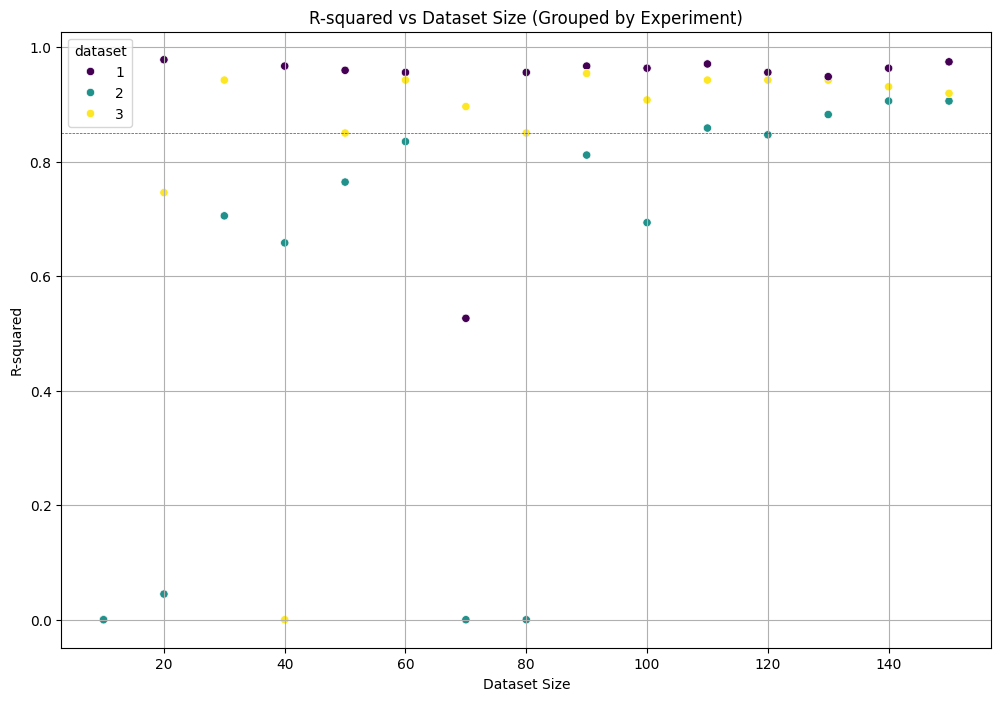

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame with model == 'yolov5lu'
filtered_df = df[df['model'] == 'yolov8n']
# Drop rows with NaN values in the 'r_squared' column
filtered_df = filtered_df.dropna(subset=['r_squared'])

# Group by 'experiment' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby('experiment')['r_squared'].idxmax()]

# set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Create a scatter plot with 'dataset_size' on the x-axis and 'r_squared' on the y-axis
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_df, x='dataset_size', y='r_squared', hue='dataset', palette='viridis')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment)')
plt.grid(True)

plt.show()

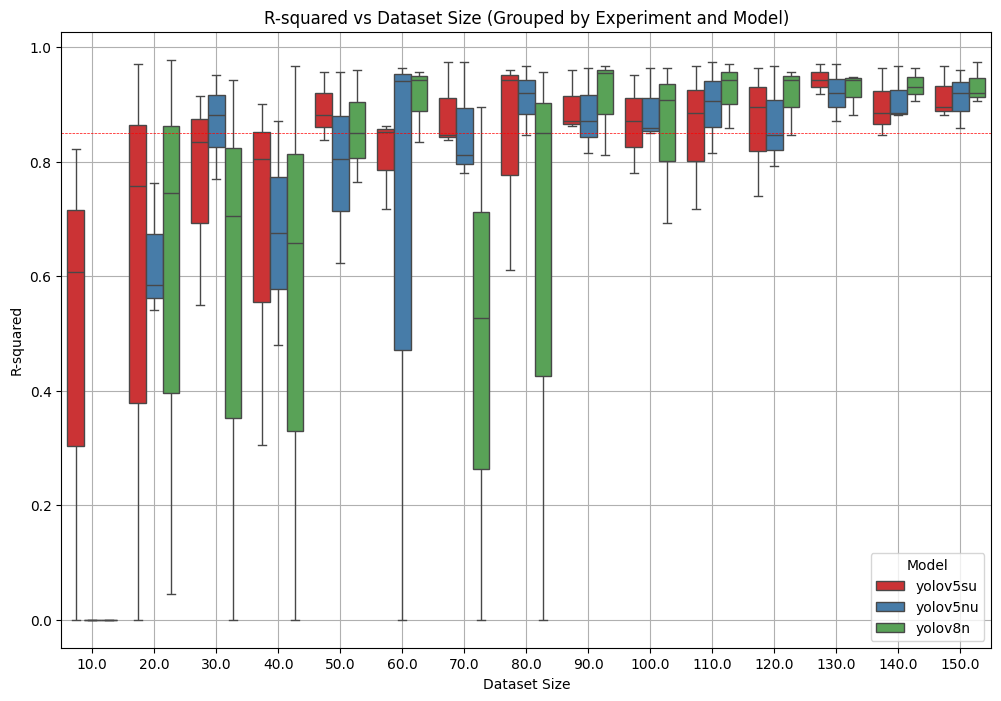

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Drop rows with NaN values in the 'r_squared' column
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov8n', 'yolov5nu', 'yolov5su'])]
# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Create a scatter plot with 'dataset_size' on the x-axis and 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.boxplot(x='dataset_size', y='r_squared', hue='model', data=filtered_df, palette='Set1')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

/tmp/ipykernel_863703/952146440.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='dataset_size', y='r_squared', hue='model', data=filtered_df, ci='sd', estimator='mean', marker='o', palette='Set1')


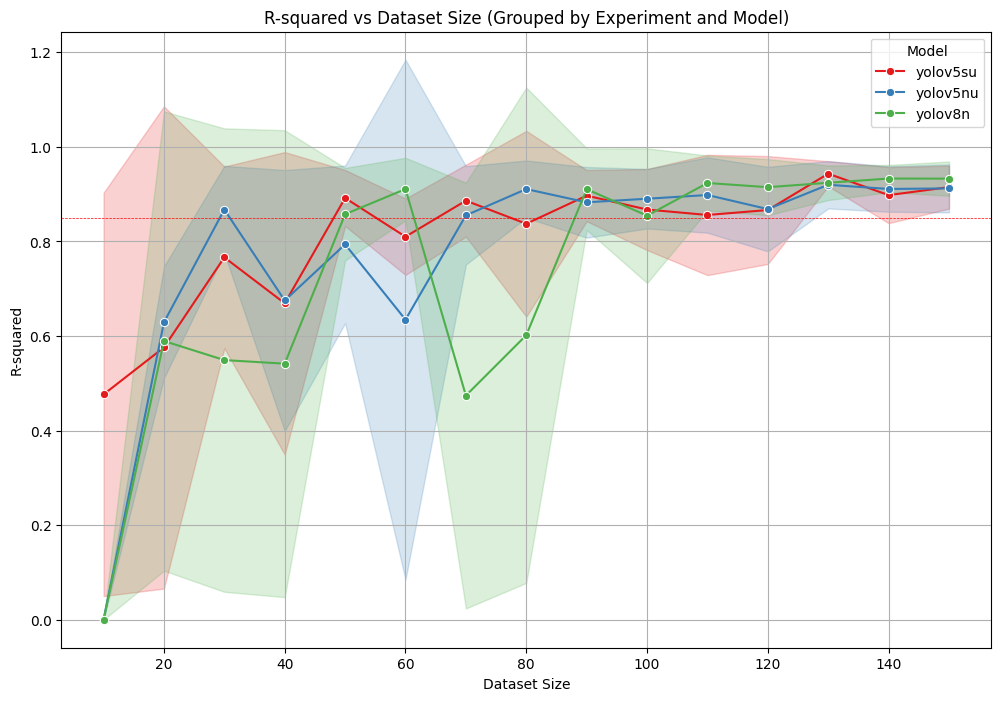

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov8n', 'yolov5nu', 'yolov5su'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', data=filtered_df, ci='sd', estimator='mean', marker='o', palette='Set1')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

/tmp/ipykernel_863703/2701281149.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, ci='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles)


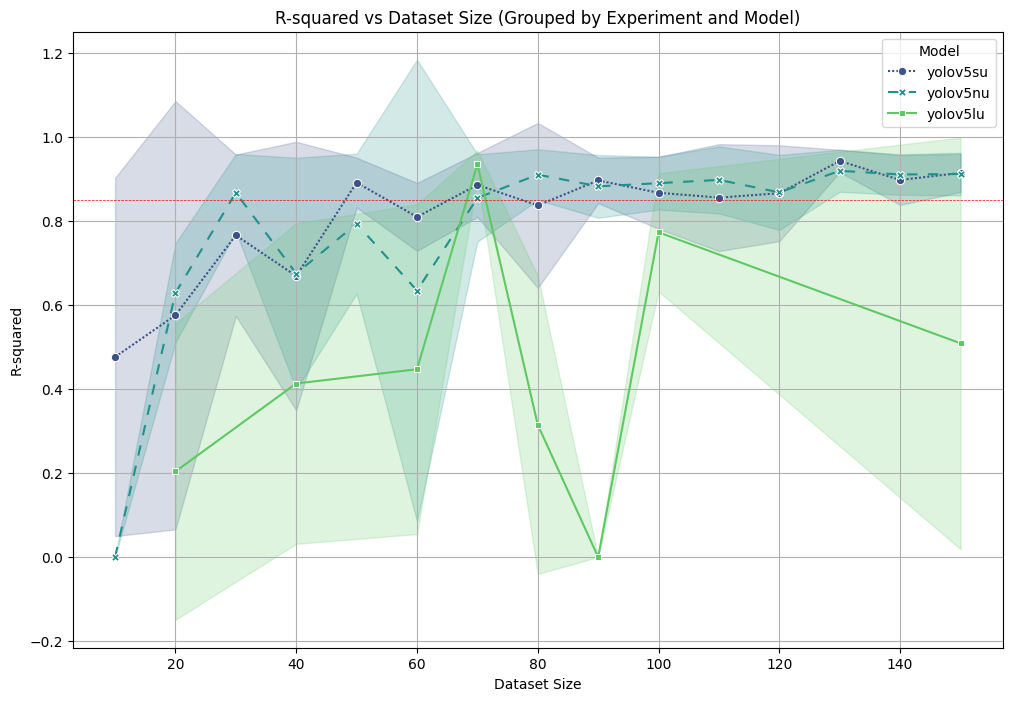

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov5lu', 'yolov5nu', 'yolov5su'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 3)
linestyles = {'yolov5lu': '', 'yolov5nu': (5, 5), 'yolov5su': (1, 1)}

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, ci='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles)

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

<Figure size 1200x800 with 0 Axes>

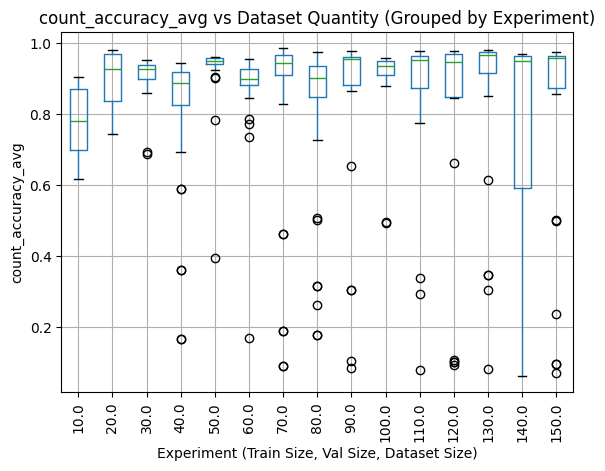

In [14]:
# Filter the DataFrame with model == 'yolov5lu'
filtered_df = df[df['model'] == 'yolov5su']

# Create a box plot with 'dataset_quantity' on the x-axis and 'r_squared' on the y-axis
plt.figure(figsize=(12, 8))
filtered_df.boxplot(column='count_accuracy_avg', by='dataset_size', grid=False, rot=90, fontsize=10)

plt.xlabel('Experiment (Train Size, Val Size, Dataset Size)')
plt.ylabel('count_accuracy_avg')
plt.title('count_accuracy_avg vs Dataset Quantity (Grouped by Experiment)')
plt.suptitle('')  # Suppress the default title to avoid overlap
plt.grid(True)

plt.show()

Correlation between dataset_size and ap_iou_50: -0.005644094364469285


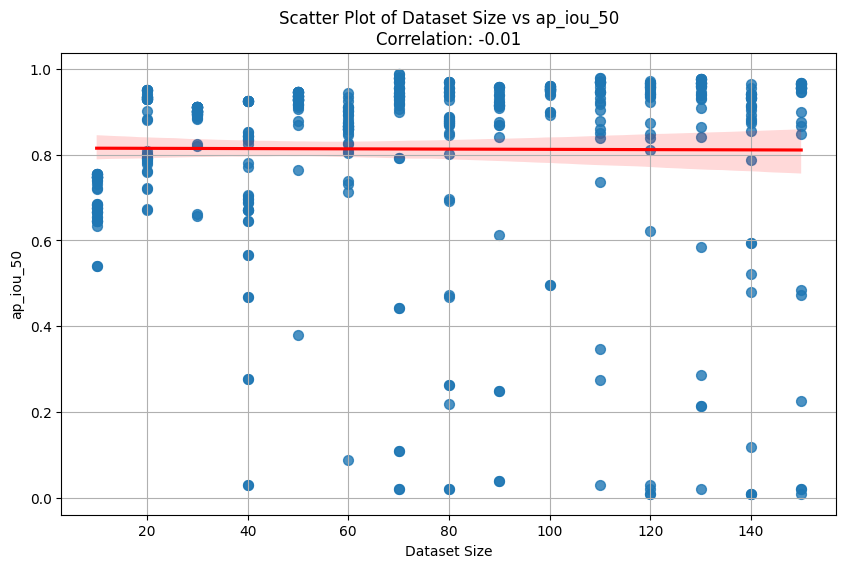

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame with model == 'yolov5lu'
filtered_df = df[df['model'] == 'yolov5su']

# Assuming filtered_df is already defined and contains the necessary columns
# Calculate the correlation between 'dataset_size' and 'r_squared'
correlation = filtered_df['dataset_size'].corr(filtered_df['ap_iou_50'])
print(f"Correlation between dataset_size and ap_iou_50: {correlation}")

# Create a scatter plot with a trend line
plt.figure(figsize=(10, 6))
sns.regplot(x='dataset_size', y='ap_iou_50', data=filtered_df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.xlabel('Dataset Size')
plt.ylabel('ap_iou_50')
plt.title(f'Scatter Plot of Dataset Size vs ap_iou_50\nCorrelation: {correlation:.2f}')
plt.grid(True)
plt.show()